# Defect calculations: supercells and a neutral Au vacancy

This notebook follows the [official ASE defect-calculation tutorial](https://docs.ase-lib.org/examples_generated/03-tutorials/defects.html), including the supercell-shape strategy discussed by Erhart *et al.* It explains why periodic defect calculations need carefully chosen supercells, compares simple two-dimensional cell shapes, constructs FCC Au supercells, and extends the geometry exercise to a relaxed neutral Au vacancy with EMT.

The first part emphasizes supercell preparation because cell shape controls the artificial periodic arrangement of defects. The final part then removes one Au atom, relaxes the remaining atoms at fixed cell, evaluates a vacancy formation energy, and checks its size dependence across a self-similar cubic series.

### Learning goals

- explain why periodic defect images create finite-size effects;
- relate nearest-image distance to supercell shape;
- describe a supercell with an integer transformation matrix;
- use ASE to search for a target cell shape and interpret its score;
- verify cell lengths, angles, and shortest periodic translations;
- generate and relax a neutral Au vacancy with EMT; and
- compare vacancy formation energies across self-similar cell sizes.

Unless stated otherwise, distances are in ångström (Å). Transformation matrices and normalized shape-deviation scores are dimensionless.

## Why supercell shape matters

A defect inserted into a periodic simulation cell is repeated in every lattice direction. The calculation therefore represents an infinite array of defects rather than one isolated defect. For a fixed number of atoms, a useful cell shape keeps the nearest periodic images as far apart as possible and avoids one especially short repeat direction.

The following geometric examples compare square, rectangular, and hexagonal periodic arrangements. The arrows identify neighboring images of a central site. Here $r_1$ is the nearest-image distance and $Z_1$ is the number of images at that distance.

For a shape-only comparison, define the effective two-dimensional length $a_0 = \sqrt{A}$ from the primitive-cell area $A$ and compare the dimensionless ratio $r_1/a_0$. The code uses different raw in-plane areas for the three constructions, but these ratios are unchanged by uniform rescaling and therefore show how the shapes would compare at equal area. The chemical symbols are only convenient ways to generate the lattices; the plots are not models of Po, C, or Be defects.

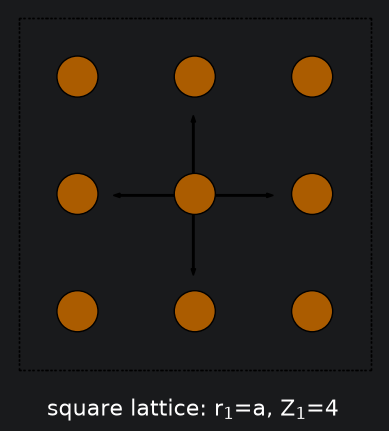

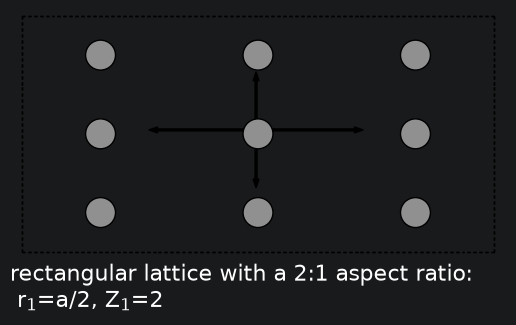

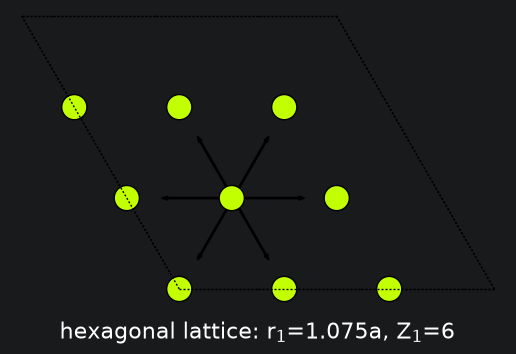

In [1]:
import matplotlib.pyplot as plt

from ase.build import bulk
from ase.geometry import get_distances
from ase.visualize.plot import plot_atoms


def add_decoration(ax, conf, centralidx, neighborcutoff, arrow_offset=(0, 0)):
    # function for adding arrows to neighboring atoms
    vectors, distances = get_distances(
        conf.positions[centralidx], p2=conf.positions
    )
    neighboridx = [
        i for i, j in enumerate(distances[0]) if (neighborcutoff >= j)
    ]

    # we normalize the size of the arrows for illustration purposes
    norm = neighborcutoff / 5
    for idx in neighboridx:
        ax.arrow(
            conf.positions[centralidx][0] + arrow_offset[0],
            conf.positions[centralidx][1] + arrow_offset[1],
            vectors[0][idx][0] / norm,
            vectors[0][idx][1] / norm,
            width=0.1,
            color='k',
        )


lattice_constant = 8
centralidx = 4
neighborcutoff = 8


# square lattice
# build structure
conf = bulk('Po', a=lattice_constant)
# moving the atom in the middle of the cell
positions = conf.get_positions()
positions += conf.cell[0][0] / 2
conf.set_positions(positions)
conf = conf.repeat((3, 3, 1))

# plot cs structure
fig, ax = plt.subplots()
add_decoration(ax, conf, centralidx, neighborcutoff, arrow_offset=(0.5, 0.5))
plot_atoms(conf, ax, offset=(0, 0))  # , rotation=('-80x,0y,0z'))
ax.set_axis_off()
ax.text(
    0.1,
    -0.1,
    'square lattice: r$_1$=a, Z$_1$=4',
    transform=ax.transAxes,
    fontsize=16,
)
plt.show()


# rectangular lattice
# build structure
conf = bulk(
    'C',
    crystalstructure='orthorhombic',
    a=lattice_constant,
    b=lattice_constant / 2,
    c=lattice_constant / 2,
)

# moving the atom in the middle of the cell
positions = conf.get_positions()
positions += [conf.cell[0][0] / 2, conf.cell[0][0] / 4, conf.cell[0][0] / 4]
conf.set_positions(positions)
conf = conf.repeat((3, 3, 1))

# plot orc structure
fig, ax = plt.subplots()
add_decoration(ax, conf, centralidx, neighborcutoff, arrow_offset=(0.5, 0.5))
plot_atoms(conf, ax, offset=(0, 0))
ax.set_axis_off()
ax.text(
    0,
    -0.2,
    'rectangular lattice with a 2:1 aspect ratio:\n r$_1$=a/2, Z$_1$=2',
    transform=ax.transAxes,
    fontsize=16,
)
plt.show()

# hexagonal lattice
# build structure
conf = bulk('Be', a=lattice_constant)
# here, we slice the cell to have one a 2D layer of atoms
confmask = [i.index for i in conf if i.position[2] < 1]
conf = conf[confmask]
conf = conf.repeat((3, 3, 1))
positions = conf.get_positions()
positions -= conf.positions[0]
conf.set_positions(positions)

# plot hpc structure
fig, ax = plt.subplots()
add_decoration(
    ax,
    conf,
    centralidx,
    neighborcutoff,
    arrow_offset=(-conf.cell[1][0] + 1, 1.5),
)
plot_atoms(conf, ax, offset=(0, 0), rotation=('0x,0y,0z'))
ax.set_axis_off()
ax.text(
    0.1,
    -0.1,
    'hexagonal lattice: r$_1$=1.075a, Z$_1$=6',
    transform=ax.transAxes,
    fontsize=16,
)
plt.show()

### Interpreting the geometric comparison

At fixed area, the square lattice has four nearest images with $r_1/a_0 = 1$. The 2:1 rectangular lattice has only two nearest images, but they are closer, with $r_1/a_0 = 1/\sqrt{2}$. The hexagonal lattice maximizes the nearest-image separation among these examples, with six images at

$$
\frac{r_1}{a_0} = \frac{\sqrt{2}}{\sqrt[4]{3}} \approx 1.075.
$$

The same principle extends to three dimensions. With $a_0 = \Omega^{1/3}$ for cell volume $\Omega$, a simple-cubic arrangement has $r_1/a_0 = 1$ and $Z_1 = 6$, while ideal FCC and HCP arrangements have

$$
\frac{r_1}{a_0} = 2^{1/6} \approx 1.1225, \qquad Z_1 = 12.
$$

Cell volume alone is therefore insufficient: the cell metric and shortest periodic-image distance also affect defect interactions.

## Finite-size effects and self-similar cells

Periodic-image interactions decrease as a supercell grows but can remain important. Charged defects in weakly screening semiconductors and insulators are especially demanding because their electrostatic interactions are long-ranged; neutral defects can also interact through elastic and electronic perturbations. A finite-size study therefore compares several cell sizes and extrapolates toward the dilute-defect limit. For a leading interaction that scales with inverse linear size,

$$
L^{-1} \propto N^{-1/3},
$$

where $N$ is the number of primitive cells or, for a fixed atomic basis, is proportional to the number of atoms. The cells in that sequence should be geometrically equivalent or as self-similar as possible. Otherwise, changes in the computed defect energy mix genuine size convergence with changes in periodic-image geometry.

## Starting from a primitive FCC cell

`bulk('Au')` creates the one-atom primitive cell of FCC Au. Its three lattice vectors are not mutually orthogonal, so a simple repetition of this primitive representation does not automatically give the most cubic cell for every requested size.

Gold is used only to demonstrate ASE's cell-transformation tools. The supercell-shape method depends on the cell metric and can be applied to another crystal before inserting the defect of interest.

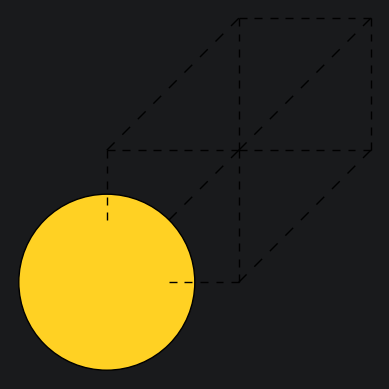

In [2]:
import matplotlib.pyplot as plt

from ase.build import bulk
from ase.visualize.plot import plot_atoms

conf = bulk('Au')


fig, ax = plt.subplots()
plot_atoms(conf, ax)
ax.set_axis_off()

## Finding an optimal transformation matrix

A supercell compatible with the primitive lattice is generated by an integer transformation matrix $\mathbf{P}$:

$$
\mathbf{h}_{\mathrm{sc}} = \mathbf{P}\mathbf{h}_{\mathrm{p}},
$$

where $\mathbf{h}_{\mathrm{p}}$ and $\mathbf{h}_{\mathrm{sc}}$ contain the primitive and supercell lattice vectors. The determinant satisfies $|\det \mathbf{P}| = N_{\mathrm{uc}}$, the number of primitive cells in the supercell.

`find_optimal_cell_shape(conf.cell, 32, 'sc')` searches integer matrices with $|\det \mathbf{P}| = 32$ and selects the cell closest to a simple-cubic (`'sc'`) target after removing the trivial size dependence. Because primitive FCC Au contains one atom, this target contains 32 atoms.

With ASE's default `score_key='length'`, candidate cells are ranked by the normalized root-sum-square deviation of their three cell-vector lengths from the target length. For a simple-cubic target, the effective target length is

$$
a_0 = |\det \mathbf{h}_{\mathrm{sc}}|^{1/3}.
$$

A score of zero is an exact length match, and smaller positive values are better. This rotationally invariant length score does **not** explicitly test the cell angles or the true minimum periodic-image distance. Those are separate geometric checks.

In [3]:
import numpy as np

from ase.build import find_optimal_cell_shape
from ase.build.supercells import eval_length_deviation

P1 = find_optimal_cell_shape(conf.cell, 32, 'sc')
print(P1)

[[-2  2  2]
 [ 2 -2  2]
 [ 2  2 -2]]


### A commensurate 32-atom cubic cell

For 32 primitive FCC cells, ASE finds the transformation

$$
\mathbf{P}_1 =
\begin{pmatrix}
-2 & 2 & 2 \\
2 & -2 & 2 \\
2 & 2 & -2
\end{pmatrix}.
$$

This is the primitive-cell representation of a $2 \times 2 \times 2$ repetition of the conventional four-atom FCC cell. It can match a simple-cubic target exactly.

### A larger, nontrivial target size

A 495-atom FCC supercell cannot form an exactly cubic conventional repetition. The same search instead returns a compatible integer matrix whose normalized cell-vector lengths are close to the simple-cubic target. This is where an optimized transformation is more useful than choosing repetition counts by inspection.

The exact matrix can depend on the ASE version and scoring implementation, and symmetry-equivalent matrices may describe the same cell quality. The printed matrix and the resulting geometry are therefore more informative than copying a matrix from another software version.

In [4]:
P2 = find_optimal_cell_shape(conf.cell, 495, 'sc')
print(P2)

[[-5  5  5]
 [ 5 -4  5]
 [ 5  5 -4]]


## Quantifying the length deviation

`eval_length_deviation()` applies the same default length-based score to an already constructed cell matrix. For a simple-cubic target, the score can be written as

$$
\overline{\Delta}_{\mathrm{length}} = \left[\sum_{i=1}^{3} \left(\frac{|\mathbf{h}_i|}{a_0} - 1\right)^2\right]^{1/2}.
$$

The score is dimensionless. It measures aggregate length mismatch, not an energy, uncertainty, or defect-interaction strength. A low value is useful for screening candidate cells, but it should be followed by checks of the cell angles and the actual minimum periodic-image distance.

In [5]:
dev1 = eval_length_deviation(np.dot(P1, conf.cell))
dev2 = eval_length_deviation(np.dot(P2, conf.cell))
print(f'The length deviation for P_1 is {dev1}')
print(f'The length deviation for P_2 is {dev2}')

The length deviation for P_1 is 3.8459253727671276e-16
The length deviation for P_2 is 0.019161199641064268


### Interpreting the scores

The value for $\mathbf{P}_1$ is approximately $3.85 \times 10^{-16}$, which is numerical roundoff around the ideal score of zero. The value for $\mathbf{P}_2$ is about 0.0192, showing a small but nonzero aggregate mismatch in the normalized vector lengths. It does not mean that every length differs by 1.92%.

## Generating the selected supercell

`make_supercell(conf, P)` applies the general integer transformation rather than restricting the construction to diagonal repetition counts. The resulting number of atoms is

$$
N_{\mathrm{sc}} = |\det \mathbf{P}|N_{\mathrm{p}},
$$

where $N_{\mathrm{p}}$ is the number of atoms in the input primitive cell. Here $N_{\mathrm{p}}=1$ and $|\det \mathbf{P}|=495$, so the generated Au cell contains 495 atoms. The code still creates a perfect crystal: no atom has yet been removed, replaced, or added.

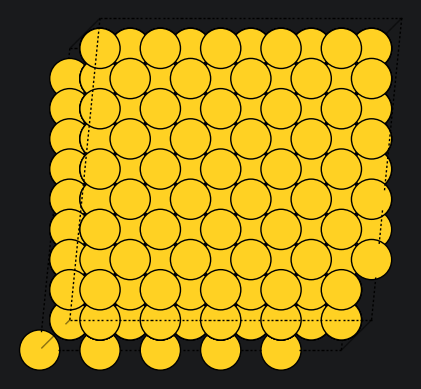

In [6]:
from ase.build import make_supercell

conf = bulk('Au')
P = find_optimal_cell_shape(conf.cell, 495, 'sc')
supercell = make_supercell(conf, P)

fig, ax = plt.subplots()
plot_atoms(supercell, ax)
ax.set_axis_off()

### Interpreting the generated structure

The plot is a two-dimensional projection of the 495-atom periodic crystal. It confirms that atoms were generated, but a projection alone cannot establish cell quality. The next cell therefore reports the determinant, atom count, three cell-vector lengths, three cell angles, and shortest nonzero periodic lattice translation for $\mathbf{P}_1$ and $\mathbf{P}_2$.

## Direct geometry diagnostics

`minkowski_reduce()` rewrites a periodic lattice using an equivalent reduced basis whose first vector is among the shortest lattice translations. The minimum reduced-vector length is therefore the separation between equivalent sites in neighboring supercells. For one defect per cell, it is the nearest separation between periodically repeated copies of that defect. This geometric distance is reported in Å and is more directly connected to defect-image separation than the length-deviation score alone.

The diagnostic table is also written to `../files/advanced/tutorial_07/cell_diagnostics.csv`. Relative paths assume that the notebook kernel is running from the `official_tutorials_advanced` directory.

In [7]:
import csv
from pathlib import Path

from ase.geometry import minkowski_reduce

tutorial_output_dir = Path('../files/advanced/tutorial_07')
tutorial_output_dir.mkdir(parents=True, exist_ok=True)

def shortest_periodic_translation(cell):
    """Return the shortest nonzero lattice translation in Å."""
    reduced_cell, _ = minkowski_reduce(cell, pbc=True)
    return np.linalg.norm(reduced_cell, axis=1).min()


cell_diagnostic_records = []

for label, transformation in [('P_1', P1), ('P_2', P2)]:
    atoms_sc = make_supercell(conf, transformation)
    determinant = int(round(abs(np.linalg.det(transformation))))
    cell_lengths = atoms_sc.cell.lengths()
    cell_angles = atoms_sc.cell.angles()
    image_distance = shortest_periodic_translation(atoms_sc.cell)
    cell_diagnostic_records.append(
        {
            'label': label,
            'determinant': determinant,
            'atom_count': len(atoms_sc),
            'cell_length_a_A': cell_lengths[0],
            'cell_length_b_A': cell_lengths[1],
            'cell_length_c_A': cell_lengths[2],
            'cell_angle_alpha_degrees': cell_angles[0],
            'cell_angle_beta_degrees': cell_angles[1],
            'cell_angle_gamma_degrees': cell_angles[2],
            'shortest_periodic_translation_A': image_distance,
        }
    )

    lengths = ', '.join(f'{value:.3f}' for value in cell_lengths)
    angles = ', '.join(f'{value:.3f}' for value in cell_angles)

    print(f'{label}: |det(P)| = {determinant}, atoms = {len(atoms_sc)}')
    print(f'  cell-vector lengths (Å): {lengths}')
    print(f'  cell angles (degrees): {angles}')
    print(f'  shortest periodic translation (Å): {image_distance:.3f}')

diagnostics_path = tutorial_output_dir / 'cell_diagnostics.csv'
with diagnostics_path.open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(
        handle, fieldnames=cell_diagnostic_records[0].keys()
    )
    writer.writeheader()
    writer.writerows(cell_diagnostic_records)

print(f'Saved geometry diagnostics to {diagnostics_path}')

P_1: |det(P)| = 32, atoms = 32
  cell-vector lengths (Å): 8.160, 8.160, 8.160
  cell angles (degrees): 90.000, 90.000, 90.000
  shortest periodic translation (Å): 8.160
P_2: |det(P)| = 495, atoms = 495
  cell-vector lengths (Å): 20.400, 20.603, 20.603
  cell angles (degrees): 78.119, 84.318, 84.318
  shortest periodic translation (Å): 20.400
Saved geometry diagnostics to ../files/advanced/tutorial_07/cell_diagnostics.csv


### What the diagnostics reveal

For $\mathbf{P}_1$, all three vectors are 8.160 Å long, all angles are 90°, and the shortest periodic translation is 8.160 Å. The 495-atom $\mathbf{P}_2$ cell has vector lengths of approximately 20.400, 20.603, and 20.603 Å, but angles of approximately 78.119°, 84.318°, and 84.318°. Its shortest periodic translation is 20.400 Å. This comparison makes the earlier caveat concrete: a small default length score does not guarantee nearly orthogonal angles.

## Neutral Au-vacancy formation energy with EMT

The vacancy calculation uses three exactly cubic, self-similar cells containing 32, 108, and 256 atoms. These sizes correspond to $2 \times 2 \times 2$, $3 \times 3 \times 3$, and $4 \times 4 \times 4$ repetitions of the conventional four-atom FCC cell, expressed here through transformation matrices acting on the one-atom primitive cell.

For each size, the workflow is:

1. construct the perfect periodic cell at ASE's default Au lattice constant of 4.08 Å;
2. evaluate its total energy with EMT;
3. remove the Au atom nearest the fractional cell center;
4. relax all remaining atomic positions with FIRE while keeping the cell fixed; and
5. stop when the maximum atomic force is below 0.01 eV/Å, or after 200 steps.

All perfect and defective cells use fresh EMT calculators with identical settings. For an elemental $N$-atom reference cell, the neutral vacancy formation energy is

$$
E_{\mathrm{f}}^{\mathrm{vac}} = E_{N-1}^{\mathrm{relaxed}} - \frac{N-1}{N}E_N^{\mathrm{perfect}}.
$$

The second term uses the perfect bulk energy per atom as the chemical potential of the removed Au atom. The relaxation energy $E_{N-1}^{\mathrm{relaxed}}-E_{N-1}^{\mathrm{unrelaxed}}$ should be non-positive because the optimizer lowers or preserves the defect energy. EMT makes this size study inexpensive, but the result is a model-potential value rather than a converged first-principles prediction.

The numerical summary is saved as `vacancy_results.csv`. The three relaxed defect structures are saved, in 32-, 108-, and 256-atom reference-cell order, as the multi-image trajectory `relaxed_vacancies.traj`.

In [8]:
from ase.calculators.emt import EMT
from ase.io import write
from ase.optimize import FIRE

vacancy_target_sizes = [32, 108, 256]
vacancy_force_tolerance = 0.01  # eV/Å
vacancy_max_steps = 200


def relax_neutral_au_vacancy(primitive, target_size, fmax, max_steps):
    """Build and relax one neutral Au vacancy in a fixed periodic cell."""
    transformation = find_optimal_cell_shape(
        primitive.cell, target_size, 'sc'
    )
    perfect = make_supercell(primitive, transformation)
    perfect.calc = EMT()
    perfect_energy = perfect.get_potential_energy()

    # Any Au site is equivalent before the vacancy is introduced.
    scaled_offsets = perfect.get_scaled_positions(wrap=True) - 0.5
    scaled_offsets -= np.rint(scaled_offsets)
    vacancy_index = np.linalg.norm(
        scaled_offsets @ perfect.cell, axis=1
    ).argmin()

    defect = perfect.copy()
    del defect[vacancy_index]
    defect.calc = EMT()
    unrelaxed_energy = defect.get_potential_energy()

    optimizer = FIRE(defect, logfile=None)
    converged = optimizer.run(fmax=fmax, steps=max_steps)
    if not converged:
        raise RuntimeError(
            f'Vacancy relaxation for N={target_size} did not converge.'
        )

    relaxed_energy = defect.get_potential_energy()
    maximum_force = np.linalg.norm(defect.get_forces(), axis=1).max()
    formation_energy = (
        relaxed_energy
        - len(defect) / len(perfect) * perfect_energy
    )

    result = {
        'n_perfect': len(perfect),
        'image_distance_A': shortest_periodic_translation(perfect.cell),
        'optimizer_steps': optimizer.nsteps,
        'max_force_eV_per_A': maximum_force,
        'relaxation_energy_eV': relaxed_energy - unrelaxed_energy,
        'formation_energy_eV': formation_energy,
    }
    defect.info['reference_atom_count'] = len(perfect)
    defect.info['vacancy_formation_energy_eV'] = formation_energy
    defect.info['max_force_eV_per_A'] = maximum_force
    return defect, result


au_primitive = bulk('Au')
vacancy_structures = {}
vacancy_results = []

for target_size in vacancy_target_sizes:
    relaxed_defect, result = relax_neutral_au_vacancy(
        au_primitive,
        target_size,
        vacancy_force_tolerance,
        vacancy_max_steps,
    )
    vacancy_structures[target_size] = relaxed_defect
    vacancy_results.append(result)

print(
    f"{'N':>4} {'image (Å)':>10} {'steps':>7} "
    f"{'Fmax (eV/Å)':>14} {'Erelax (eV)':>13} {'Eform (eV)':>11}"
)
for result in vacancy_results:
    print(
        f"{result['n_perfect']:4d} "
        f"{result['image_distance_A']:10.3f} "
        f"{result['optimizer_steps']:7d} "
        f"{result['max_force_eV_per_A']:14.4f} "
        f"{result['relaxation_energy_eV']:13.6f} "
        f"{result['formation_energy_eV']:11.6f}"
    )

vacancy_results_path = tutorial_output_dir / 'vacancy_results.csv'
with vacancy_results_path.open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=vacancy_results[0].keys())
    writer.writeheader()
    writer.writerows(vacancy_results)

vacancy_trajectory_path = tutorial_output_dir / 'relaxed_vacancies.traj'
write(
    vacancy_trajectory_path,
    [vacancy_structures[size] for size in vacancy_target_sizes],
)

print(f'Saved vacancy results to {vacancy_results_path}')
print(f'Saved relaxed structures to {vacancy_trajectory_path}')

   N  image (Å)   steps    Fmax (eV/Å)   Erelax (eV)  Eform (eV)
  32      8.160       5         0.0088     -0.003008    0.817316
 108     12.240      15         0.0098     -0.009185    0.811126
 256     16.320      15         0.0094     -0.010478    0.809832
Saved vacancy results to ../files/advanced/tutorial_07/vacancy_results.csv
Saved relaxed structures to ../files/advanced/tutorial_07/relaxed_vacancies.traj


## Finite-size trend

Because the three cells are exactly self-similar, $N^{-1/3}$ is proportional to inverse linear size without an additional change of shape. The next cell plots the relaxed formation energies and adds the three-point linear model

$$
E_{\mathrm{f}}(N) = E_{\mathrm{f}}(\infty) + bN^{-1/3}.
$$

The intercept at $N^{-1/3}=0$ is an illustrative dilute-limit estimate. With only three small cells and no comparison of alternative scaling forms, it should be treated as a visual convergence guide rather than a rigorous extrapolation. The rendered figure is saved as `../files/advanced/tutorial_07/vacancy_size_trend.png`.

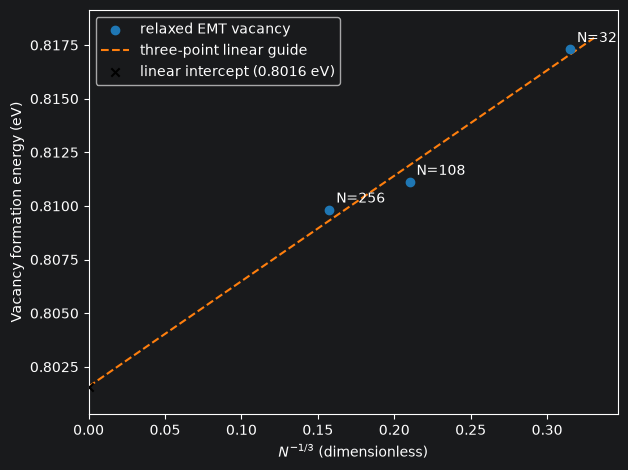

Illustrative dilute-limit intercept: 0.801576 eV


In [9]:
cell_sizes = np.array(
    [result['n_perfect'] for result in vacancy_results], dtype=float
)
formation_energies = np.array(
    [result['formation_energy_eV'] for result in vacancy_results]
)
inverse_linear_sizes = cell_sizes ** (-1 / 3)
slope, dilute_limit_energy = np.polyfit(
    inverse_linear_sizes, formation_energies, 1
)

fit_x = np.linspace(0.0, inverse_linear_sizes.max() * 1.05, 100)
fit_y = slope * fit_x + dilute_limit_energy

fig, ax = plt.subplots()
ax.scatter(
    inverse_linear_sizes,
    formation_energies,
    color='tab:blue',
    zorder=3,
    label='relaxed EMT vacancy',
)
ax.plot(
    fit_x,
    fit_y,
    linestyle='--',
    color='tab:orange',
    label='three-point linear guide',
)
for x_value, energy, size in zip(
    inverse_linear_sizes, formation_energies, cell_sizes.astype(int)
):
    ax.annotate(f'N={size}', (x_value, energy), xytext=(5, 5),
                textcoords='offset points')

ax.scatter(
    0.0,
    dilute_limit_energy,
    marker='x',
    color='black',
    zorder=4,
    label=f'linear intercept ({dilute_limit_energy:.4f} eV)',
)
ax.set_xlabel(r'$N^{-1/3}$ (dimensionless)')
ax.set_ylabel('Vacancy formation energy (eV)')
ax.set_xlim(0.0, inverse_linear_sizes.max() * 1.10)
ax.margins(y=0.08)
ax.legend()
fig.tight_layout()
plt.show()

print(f'Illustrative dilute-limit intercept: {dilute_limit_energy:.6f} eV')

### Interpreting the vacancy results

With ASE 3.29 and the settings above, the validated run gives formation energies of approximately 0.8173, 0.8111, and 0.8098 eV for the 32-, 108-, and 256-atom reference cells. The relaxation energies are negative, and every final maximum force is below 0.01 eV/Å. The three-point linear intercept is approximately 0.8016 eV.

The formation energy changes less as the cell grows, which is consistent with convergence toward an isolated-vacancy limit within this EMT model. The difference between the 108- and 256-atom values is about 0.0013 eV, but this agreement does not establish first-principles accuracy: it only shows small residual size dependence for this calculator, lattice constant, fixed-cell protocol, and cell sequence.

### Saved artifacts

Running the notebook from `official_tutorials_advanced` creates four files under `files/advanced/tutorial_07`: `cell_diagnostics.csv`, `vacancy_results.csv` and `relaxed_vacancies.traj`. The CSV headers include units, the trajectory retains the reference atom count and calculated vacancy properties in each image's `info` dictionary.

## Takeaways and possible extensions

This notebook now connects the full tutorial chain: supercell shape determines periodic-image geometry; direct diagnostics test what the shape score omits; removing one atom creates a neutral vacancy; structural relaxation lowers the defective-cell energy; and a self-similar size series exposes the remaining finite-size trend.

Useful next extensions are to optimize the EMT Au lattice constant before creating the cells, quantify neighbor displacements around the vacancy, add more sizes before fitting the dilute limit, compare `score_key='length'` with `score_key='metric'`, and repeat the workflow with a higher-accuracy calculator before interpreting quantitative defect chemistry. A climbing-image nudged elastic band calculation would then extend the static vacancy calculation to a vacancy-migration barrier.

Charged defects and multicomponent materials require additional choices that are outside this EMT example, including charge state, elemental chemical potentials, Fermi-level reference, potential alignment, and electrostatic finite-size corrections.

### Further reading

- [ASE defect-calculation tools](https://docs.ase-lib.org/examples_generated/03-tutorials/defects.html)
- [Erhart *et al.*, *Physical Review B* **91**, 165206 (2015)](https://doi.org/10.1103/PhysRevB.91.165206), especially Appendix C
- [Kavanagh *et al.*, *Journal of Open Source Software* **9**, 6433 (2024)](https://doi.org/10.21105/joss.06433) for direct optimization of periodic defect separation